# Clustering de Clientes con K-means

En este notebook construimos la segmentación de clientes usando **K-means** con tres variables: `age`, `annual_income_k` y `spending_score`.

**Ruta del notebook:**
1. Repaso teórico: qué es el clustering y cómo funciona K-means.
2. Carga de datos y selección de features (se excluye `gender`).
3. Estandarización de las variables.
4. Entrenamiento y gráficas para **k = 3, 4, 5, 6 y 10**.
5. **Método del codo (elbow)** para elegir el número óptimo de clusters.
6. Conclusiones.

## 0. Teoría: ¿qué es el clustering y cómo funciona K-means?

### Clustering
Es una técnica de **aprendizaje no supervisado**: no existe una columna "respuesta" (no hay $y$). El objetivo es encontrar grupos de observaciones que sean:
- **Parecidas entre sí** dentro del mismo grupo (alta cohesión).
- **Diferentes** a las de otros grupos (alta separación).

"Parecido" se mide con una **distancia**. K-means usa la **distancia euclidiana**:

$$d(\mathbf{x}, \boldsymbol{\mu}) = \sqrt{\sum_{j=1}^{p} (x_j - \mu_j)^2}$$

donde $p$ es el número de variables (aquí $p = 3$).

### La función que K-means minimiza
Dado un número de clusters $k$, K-means busca los centroides $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$ que minimizan la **inercia** o **WCSS** (*Within-Cluster Sum of Squares*):

$$J = \sum_{c=1}^{k} \sum_{\mathbf{x}_i \in C_c} \lVert \mathbf{x}_i - \boldsymbol{\mu}_c \rVert^2$$

Es decir: la suma de las distancias al cuadrado de cada cliente a su centroide. Un $J$ pequeño = clusters compactos.

### El algoritmo (Lloyd) paso a paso
1. **Elegir $k$** (lo decide el analista; por eso existe el método del codo).
2. **Inicializar** $k$ centroides. Usamos **k-means++**: el primer centroide se elige al azar y los siguientes con probabilidad proporcional a $d(\mathbf{x})^2$ (la distancia al centroide más cercano ya elegido). Así los centroides iniciales quedan separados.
3. **Asignación:** cada punto se asigna al centroide más cercano: $C_c = \{\mathbf{x}_i : \lVert \mathbf{x}_i - \boldsymbol{\mu}_c \rVert \le \lVert \mathbf{x}_i - \boldsymbol{\mu}_l \rVert \;\forall l\}$.
4. **Actualización:** cada centroide se mueve a la **media** de sus puntos: $\boldsymbol{\mu}_c = \frac{1}{|C_c|}\sum_{\mathbf{x}_i \in C_c} \mathbf{x}_i$.
   *¿Por qué la media?* Si derivamos $\sum_i \lVert \mathbf{x}_i - \boldsymbol{\mu}\rVert^2$ respecto a $\boldsymbol{\mu}$ e igualamos a cero: $-2\sum_i(\mathbf{x}_i - \boldsymbol{\mu}) = 0 \Rightarrow \boldsymbol{\mu} = \bar{\mathbf{x}}$. La media es exactamente el punto que minimiza la suma de cuadrados.
5. **Repetir** 3 y 4 hasta que las asignaciones ya no cambien (convergencia).

**Propiedad clave:** los pasos 3 y 4 nunca aumentan $J$, así que el algoritmo siempre converge… pero a un **mínimo local**, no necesariamente al global. Por eso se ejecuta varias veces con inicializaciones distintas (`n_init=10`) y se queda la de menor inercia.

### Supuestos y limitaciones de K-means
- Supone clusters **esféricos** y de tamaño/dispersión parecidos (porque usa distancia euclidiana a un centro).
- Es **sensible a la escala** de las variables → hay que estandarizar.
- Es **sensible a outliers** (la media se "jala" hacia los valores extremos).
- **Hay que fijar $k$ de antemano.**

*Alternativas si estos supuestos no se cumplen:* DBSCAN (clusters de forma arbitraria y detecta ruido), Gaussian Mixture Models (clusters elípticos y asignación probabilística), clustering jerárquico (no requiere fijar $k$ al inicio; se decide cortando el dendrograma).

## 1. Librerías y carga de datos

In [1]:
import warnings
warnings.filterwarnings('ignore')  # Ocultamos avisos no críticos para que la salida sea legible

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler  # Estandarización z-score
from sklearn.cluster import KMeans                # Algoritmo K-means
from sklearn.metrics import silhouette_score      # Métrica complementaria al codo

sns.set_theme(style='whitegrid')

# Semilla fija: K-means tiene una parte aleatoria (inicialización k-means++).
# Fijarla hace que los resultados sean reproducibles cada vez que se ejecuta el notebook.
SEMILLA = 42

In [2]:
# Buscamos el CSV en la carpeta data. Según desde dónde el IDE lance el kernel,
# la carpeta de trabajo puede ser la raíz del proyecto o una subcarpeta, por eso probamos ambas rutas.
ruta_csv = Path('data/retailmax.csv')
if not ruta_csv.exists():
    ruta_csv = Path('../data/retailmax.csv')

df = pd.read_csv(ruta_csv)

# Mismos nombres de columnas que en el EDA (snake_case, sin unidades ni espacios)
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income_k',
    'Spending Score (1-100)': 'spending_score'
})
df['gender'] = df['gender'].astype('category')

print('Dimensiones:', df.shape)
df.head()

Dimensiones: (200, 5)


,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Selección de features: ¿por qué excluimos `gender`?

Usaremos solo **`age`, `annual_income_k` y `spending_score`**.

**Ventajas de excluir `gender`:**
- K-means calcula **medias** y **distancias euclidianas**. `gender` es categórica; para usarla habría que codificarla como 0/1 (One-Hot). Una variable binaria solo toma dos valores, así que crea una "grieta" artificial que parte el espacio en dos: el algoritmo tendería a separar hombres y mujeres aunque se comporten igual.
- El "centroide" de una variable 0/1 sería algo como 0.56, que no representa a ninguna persona real.
- En el EDA (insights 2, 6 y 8) vimos que el género **no diferencia** ni el ingreso ni los grupos de gasto: aportaría ruido, no señal.

**Desventajas / riesgos de excluirla:**
- Si el negocio necesita campañas por género, el modelo no lo tendrá en cuenta directamente.
- Perdemos una dimensión que, en otro dataset, sí podría ser relevante.

**Alternativas:** usar `gender` solo como variable **descriptiva** después de formar los clusters (es lo que haremos: veremos el % de mujeres por cluster) o usar **K-prototypes**, una variante de K-means diseñada para mezclar variables numéricas y categóricas.

In [3]:
# Features del modelo (las tres numéricas)
FEATURES = ['age', 'annual_income_k', 'spending_score']

# Nombres legibles para los ejes de las gráficas
ETIQUETAS = {
    'age': 'Edad (años)',
    'annual_income_k': 'Ingreso anual (k$)',
    'spending_score': 'Spending score (1-100)'
}

X = df[FEATURES].copy()

# Revisamos media, desviación y rango: las escalas son muy distintas entre variables
X.describe().T[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
age,38.85,13.97,18.0,70.0
annual_income_k,60.56,26.26,15.0,137.0
spending_score,50.20,25.82,1.0,99.0


## 3. Estandarización (z-score)

Transformamos cada variable con:

$$z = \frac{x - \bar{x}}{\sigma}$$

Después de esto cada variable tiene **media 0 y desviación estándar 1**.

**¿Por qué es necesario?** La distancia euclidiana suma diferencias al cuadrado. Si una variable tiene un rango mayor, sus diferencias pesan más en la distancia **solo por sus unidades**, no por ser más importante. Ejemplo: una diferencia de 40 k\$ de ingreso aporta $40^2 = 1600$ a la distancia, mientras que 10 años de edad aportan $10^2 = 100$. Al estandarizar, cada variable se mide en "número de desviaciones estándar" y todas pesan igual.

**Desventajas:**
- Asume que **todas las variables deben pesar lo mismo**; quizá para el negocio el gasto sea más importante que la edad.
- La media y la desviación estándar son **sensibles a outliers** (en este dataset no hay outliers fuertes, lo vimos en el EDA).
- Los valores estandarizados ya no se leen en unidades reales. Por eso, para graficar e interpretar, regresaremos los centroides a sus unidades originales con `inverse_transform`.

**Alternativas:** `MinMaxScaler` (lleva todo a $[0, 1]$; muy sensible a extremos) o `RobustScaler` (usa mediana y rango intercuartílico; resistente a outliers).

**Nota sobre data leakage:** en clustering no hay un conjunto de prueba con respuestas que "espiar", así que ajustar el escalador con los 200 clientes es la práctica estándar. Lo importante para producción es **guardar este mismo escalador** y usar solo `transform` (nunca `fit`) sobre clientes nuevos.

In [4]:
# fit: calcula media y desviación de cada columna | transform: aplica z = (x - media) / desviación
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Comprobación: medias ≈ 0 y desviaciones ≈ 1.
# (pandas usa n-1 en el denominador y sklearn usa n; por eso pandas muestra 1.003 y no 1.000)
pd.DataFrame(X_scaled, columns=FEATURES).describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
age,-0.0,1.003,-1.496,2.236
annual_income_k,-0.0,1.003,-1.739,2.918
spending_score,-0.0,1.003,-1.910,1.894


## 4. Clustering con k = 3, 4, 5, 6 y 10

Para cada valor de $k$ vamos a:
1. Entrenar K-means sobre los datos **estandarizados**.
2. Regresar los centroides a unidades reales (`inverse_transform`) para poder leerlos.
3. Graficar cada cluster con tres vistas:
   - **3D:** las tres features a la vez (es el espacio real donde trabaja K-means).
   - **Ingreso vs. Spending score** y **Edad vs. Spending score:** proyecciones 2D, más fáciles de leer.
   - Los centroides se marcan con una **X negra**.
4. Mostrar el **perfil** de cada cluster (tamaño y medias) y el % de mujeres como variable descriptiva.

**Parámetros de `KMeans`:**
- `n_clusters=k`: número de grupos.
- `init='k-means++'`: inicialización inteligente (centroides iniciales separados).
- `n_init=10`: se ejecuta 10 veces con inicializaciones distintas y se queda la de menor inercia (reduce el riesgo de un mal mínimo local).
- `random_state=SEMILLA`: reproducibilidad.

**Importante al leer las proyecciones 2D:** dos clusters pueden verse encimados en una vista 2D y estar separados en la tercera dimensión (por ejemplo, por edad). Por eso siempre hay que revisar las tres vistas juntas.

In [5]:
def entrenar_kmeans(k, X_esc):
    # Crea y entrena un modelo K-means con k clusters; devuelve el modelo y la etiqueta de cada cliente
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA)
    etiquetas = modelo.fit_predict(X_esc)
    return modelo, etiquetas


def graficar_clusters(k, etiquetas, centroides):
    # Colores cualitativos (tab10 tiene 10 colores distinguibles, suficiente hasta k = 10)
    colores = sns.color_palette('tab10', n_colors=k)
    fig = plt.figure(figsize=(20, 6))

    # --- Vista 3D: las tres features que usa el modelo ---
    ax3d = fig.add_subplot(1, 3, 1, projection='3d')
    for c in range(k):
        mascara = etiquetas == c
        ax3d.scatter(X.loc[mascara, 'age'], X.loc[mascara, 'annual_income_k'], X.loc[mascara, 'spending_score'],
                     color=colores[c], s=35, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax3d.scatter(centroides['age'], centroides['annual_income_k'], centroides['spending_score'],
                 color='black', marker='X', s=220, depthshade=False)
    ax3d.set_xlabel(ETIQUETAS['age'])
    ax3d.set_ylabel(ETIQUETAS['annual_income_k'])
    ax3d.set_zlabel(ETIQUETAS['spending_score'])
    ax3d.set_title('Vista 3D (edad, ingreso, gasto)', fontsize=12, fontweight='bold')
    ax3d.view_init(elev=20, azim=-60)

    # --- Proyecciones 2D ---
    pares = [('annual_income_k', 'spending_score'), ('age', 'spending_score')]
    for i, (fx, fy) in enumerate(pares, start=2):
        ax = fig.add_subplot(1, 3, i)
        for c in range(k):
            mascara = etiquetas == c
            ax.scatter(X.loc[mascara, fx], X.loc[mascara, fy], color=colores[c], s=45, alpha=0.8,
                       edgecolor='white', linewidth=0.4, label=f'Cluster {c}')
        ax.scatter(centroides[fx], centroides[fy], color='black', marker='X', s=220, label='Centroide')
        ax.set_xlabel(ETIQUETAS[fx])
        ax.set_ylabel(ETIQUETAS[fy])
        ax.set_title(f'{ETIQUETAS[fx]} vs. {ETIQUETAS[fy]}', fontsize=12, fontweight='bold')

    # Una sola leyenda para toda la figura (a la derecha)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', fontsize=10, frameon=True)
    fig.suptitle(f'K-means con k = {k}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    plt.show()


def perfil_clusters(etiquetas):
    # Resumen por cluster en unidades reales; gender se usa solo para DESCRIBIR, no entró al modelo
    perfil = (df.assign(cluster=etiquetas, es_mujer=(df['gender'] == 'Female'))
                .groupby('cluster')
                .agg(n_clientes=('age', 'size'),
                     edad_media=('age', 'mean'),
                     ingreso_medio_k=('annual_income_k', 'mean'),
                     gasto_medio=('spending_score', 'mean'),
                     pct_mujeres=('es_mujer', 'mean')))
    perfil['pct_mujeres'] = (perfil['pct_mujeres'] * 100)
    return perfil.round(1)


# Aquí guardamos los resultados de cada k para compararlos al final
resultados = {}


def ejecutar_k(k):
    # Entrena, grafica y resume un modelo con k clusters
    modelo, etiquetas = entrenar_kmeans(k, X_scaled)
    # Centroides de vuelta a unidades reales (años, k$, puntos) para poder interpretarlos
    centroides = pd.DataFrame(scaler.inverse_transform(modelo.cluster_centers_), columns=FEATURES)
    silueta = silhouette_score(X_scaled, etiquetas)
    resultados[k] = {'inercia': modelo.inertia_, 'silueta': silueta}

    graficar_clusters(k, etiquetas, centroides)
    print(f'Inercia (WCSS): {modelo.inertia_:.2f}   |   Coeficiente de silueta: {silueta:.3f}')
    return perfil_clusters(etiquetas)

### k = 3

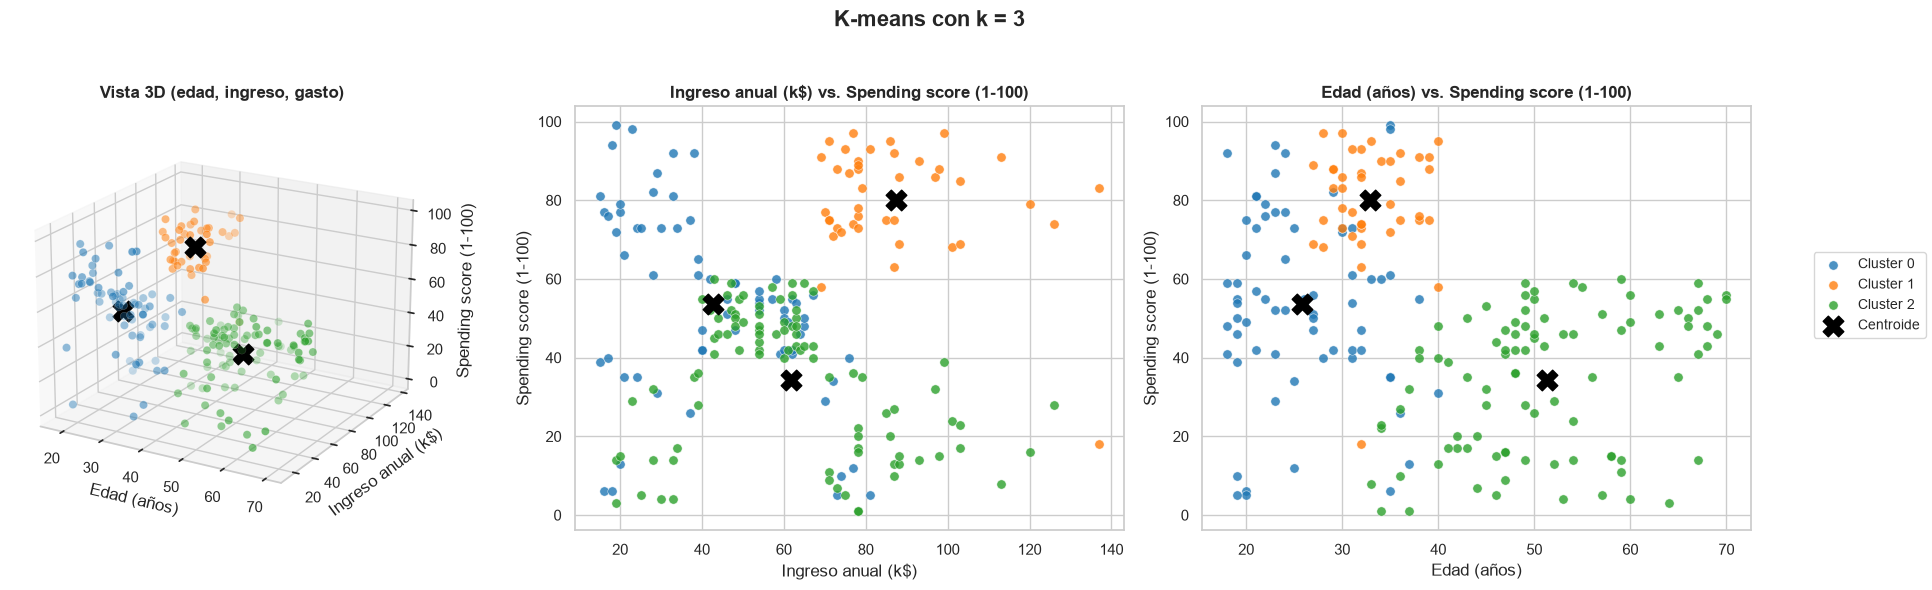

Inercia (WCSS): 295.21   |   Coeficiente de silueta: 0.358


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,68,25.8,42.8,53.6,58.8
1,41,32.9,87.3,80.0,53.7
2,91,51.3,61.8,34.2,54.9


In [6]:
ejecutar_k(3)

**Lectura:** con solo 3 grupos el modelo hace una división muy gruesa:
- **Jóvenes (~26 años) de ingreso bajo-medio** con gasto medio (~54).
- **Clientes premium (~33 años):** ingreso alto (~87 k\$) y gasto alto (~80).
- **Mayores (~51 años)**, el grupo más grande (91 clientes), que mezcla ingresos bajos y altos con gasto bajo.

El tercer grupo es demasiado heterogéneo: junta a los "ahorradores de ingreso alto" con clientes de ingreso bajo. Es señal de **subsegmentación** ($k$ muy pequeño).

### k = 4

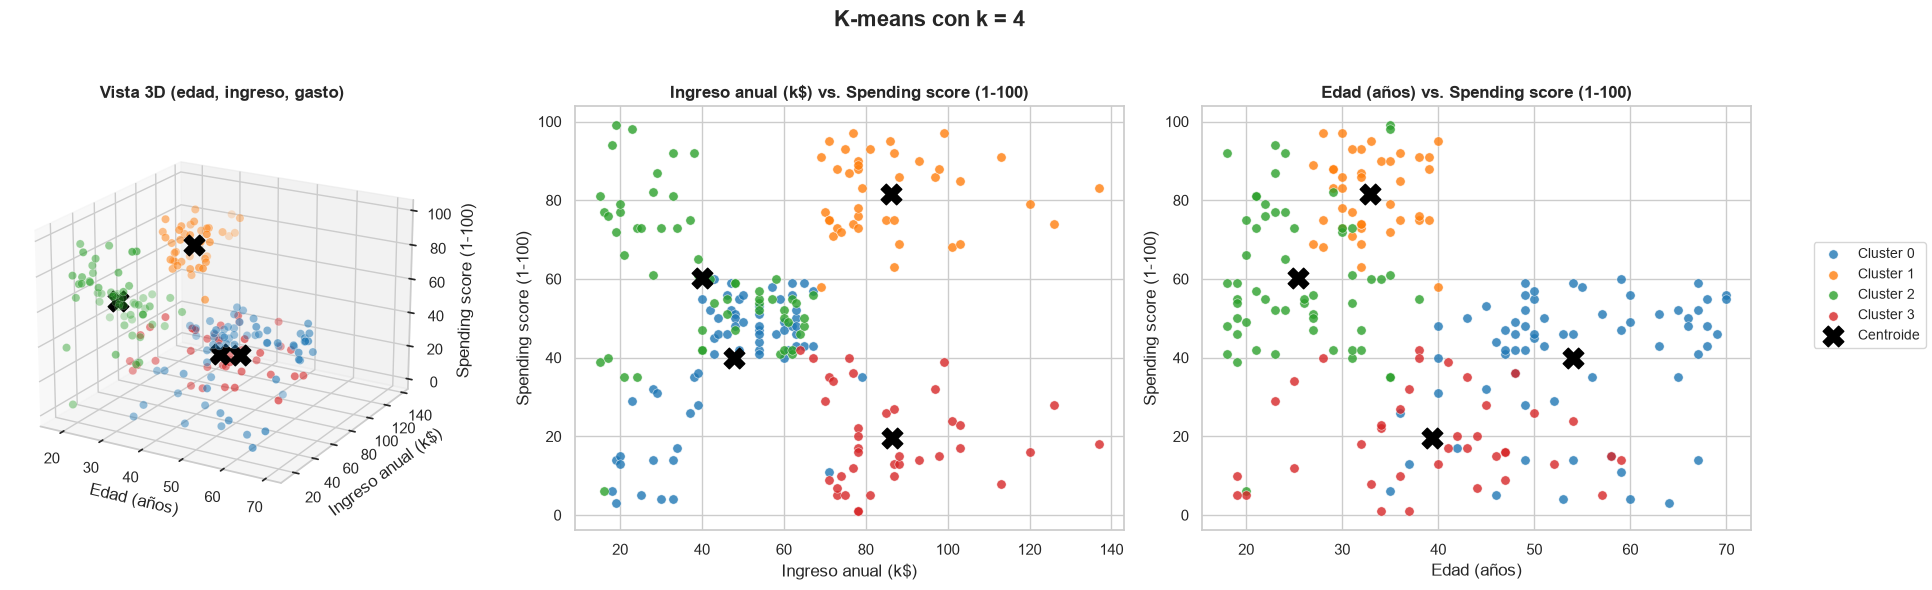

Inercia (WCSS): 205.23   |   Coeficiente de silueta: 0.404


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,65,54.0,47.7,40.0,56.9
1,40,32.9,86.1,81.5,55.0
2,57,25.4,40.0,60.3,59.6
3,38,39.4,86.5,19.6,50.0


In [7]:
ejecutar_k(4)

**Lectura:** al pasar a 4 clusters aparece un grupo nuevo muy claro: los **ahorradores** (ingreso alto ~86 k\$, gasto muy bajo ~20), que con k = 3 estaban escondidos dentro del grupo de mayores.
- Mayores (~54 años) de ingreso medio-bajo y gasto moderado.
- Premium (ingreso y gasto altos).
- Jóvenes (~25 años) de ingreso bajo-medio y gasto medio-alto.
- Ahorradores de ingreso alto.

La inercia baja mucho (de 295 a 205, −30%): separar a los ahorradores fue una ganancia grande.

### k = 5

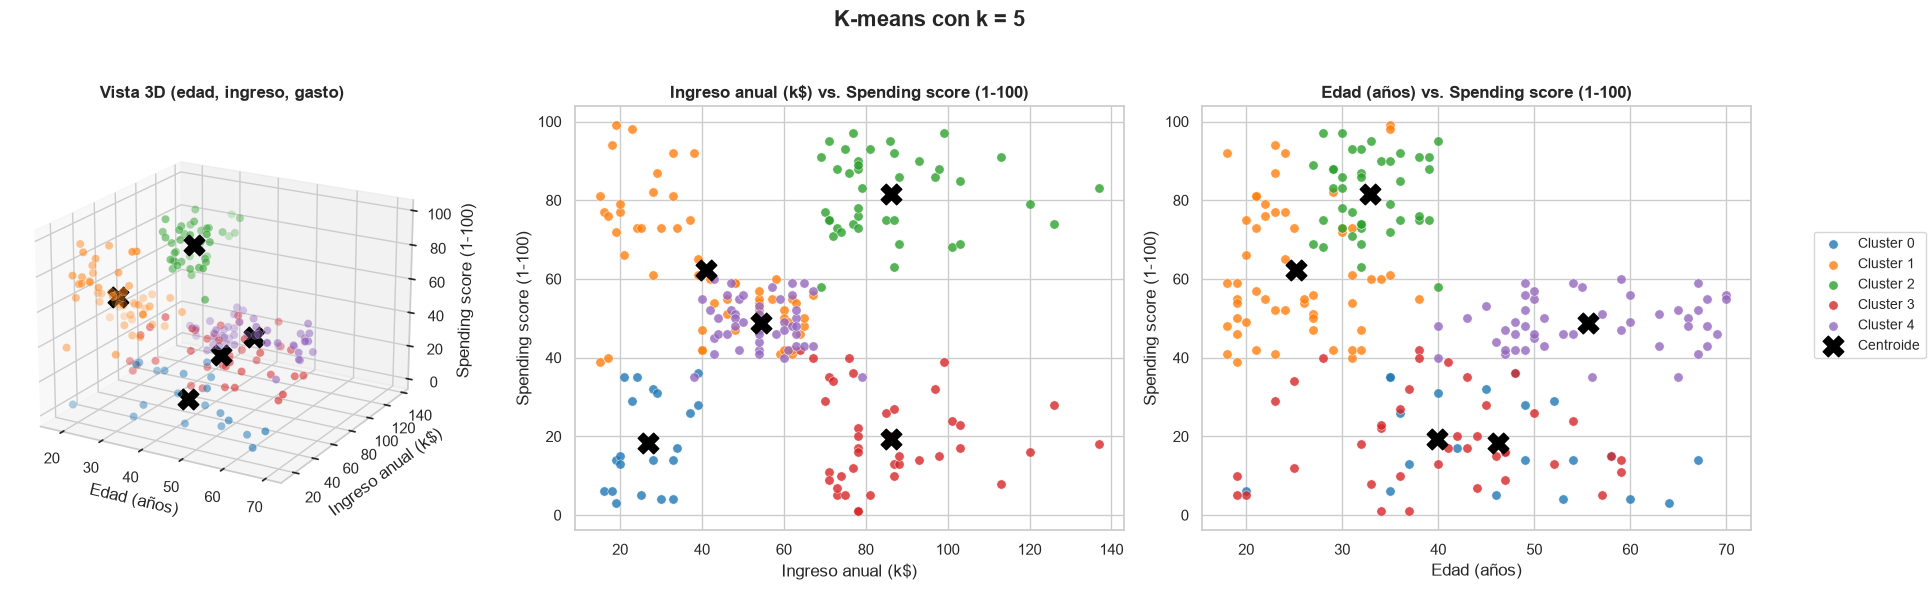

Inercia (WCSS): 168.25   |   Coeficiente de silueta: 0.417


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,20,46.2,26.8,18.4,60.0
1,54,25.2,41.1,62.2,59.3
2,40,32.9,86.1,81.5,55.0
3,39,39.9,86.1,19.4,48.7
4,47,55.6,54.4,48.9,57.4


In [8]:
ejecutar_k(5)

**Lectura:** ahora se separa un grupo de **ingreso bajo y gasto bajo** (~27 k\$, gasto ~18, edad ~46). La segmentación se parece mucho a los cinco grupos que vimos a simple vista en el EDA (insight 6), aunque aquí la **edad** también participa:
- Ingreso bajo / gasto bajo (mayores de ~46 años).
- Jóvenes (~25 años) de ingreso bajo-medio y gasto alto.
- Premium: ingreso alto / gasto alto.
- Ahorradores: ingreso alto / gasto bajo.
- Mayores (~56 años) de ingreso medio y gasto medio.

Los perfiles son fáciles de explicar al negocio, lo cual es tan importante como las métricas.

### k = 6

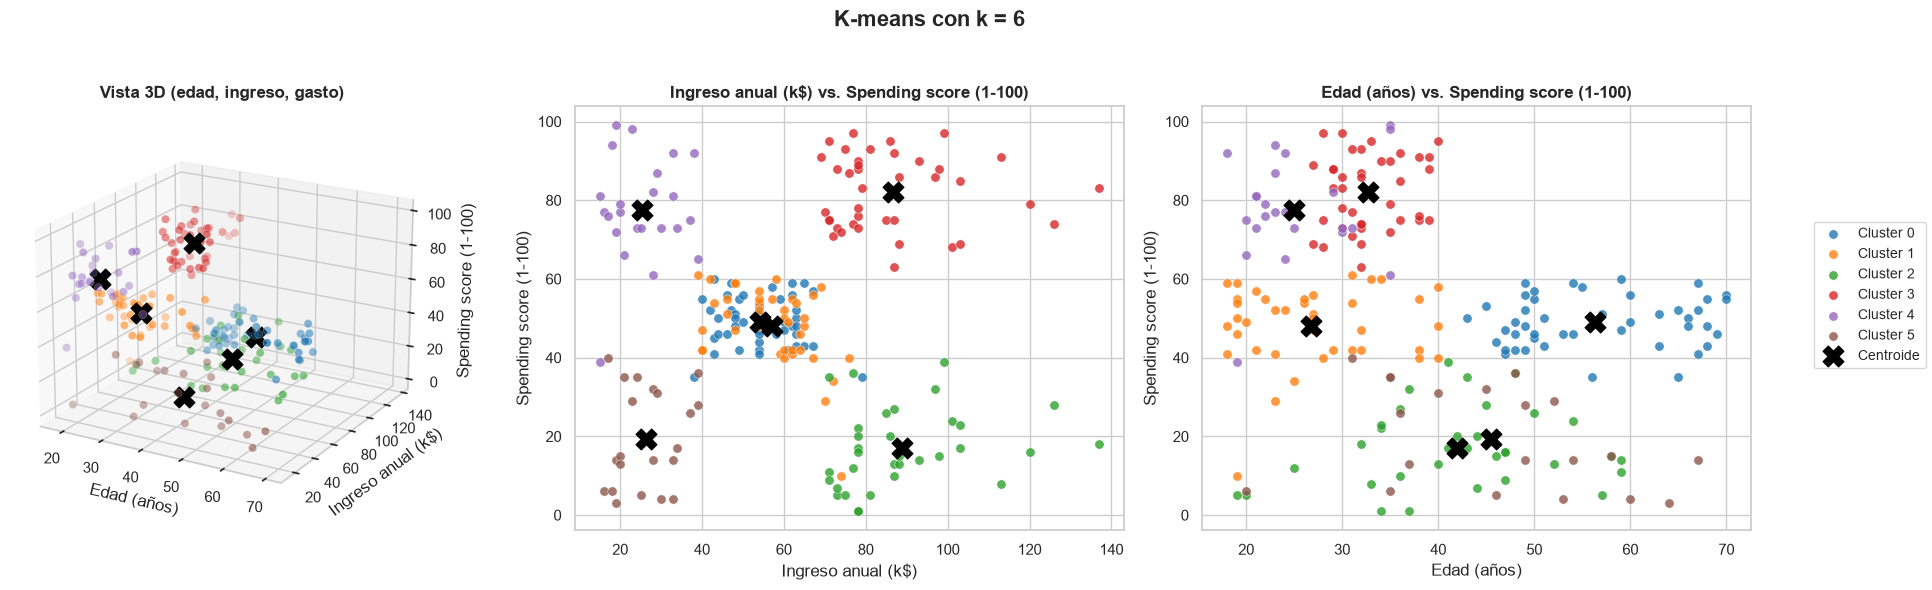

Inercia (WCSS): 133.87   |   Coeficiente de silueta: 0.428


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,45,56.3,54.3,49.1,57.8
1,39,26.8,57.1,48.1,64.1
2,33,41.9,88.9,17.0,42.4
3,39,32.7,86.5,82.1,53.8
4,23,25.0,25.3,77.6,56.5
5,21,45.5,26.3,19.4,61.9


In [9]:
ejecutar_k(6)

**Lectura:** el grupo "medio" se divide **por edad** en jóvenes (~27 años) y mayores (~56 años), ambos con ingreso y gasto medios. También se aísla un grupo de **jóvenes con ingreso bajo y gasto alto** (~25 años, 25 k\$, gasto ~78: los "compradores impulsivos" del EDA).

Esta es la $k$ con **mayor silueta** de las cinco (0.428). Los grupos siguen siendo interpretables, pero algunos ya son pequeños (21–23 clientes).

### k = 10

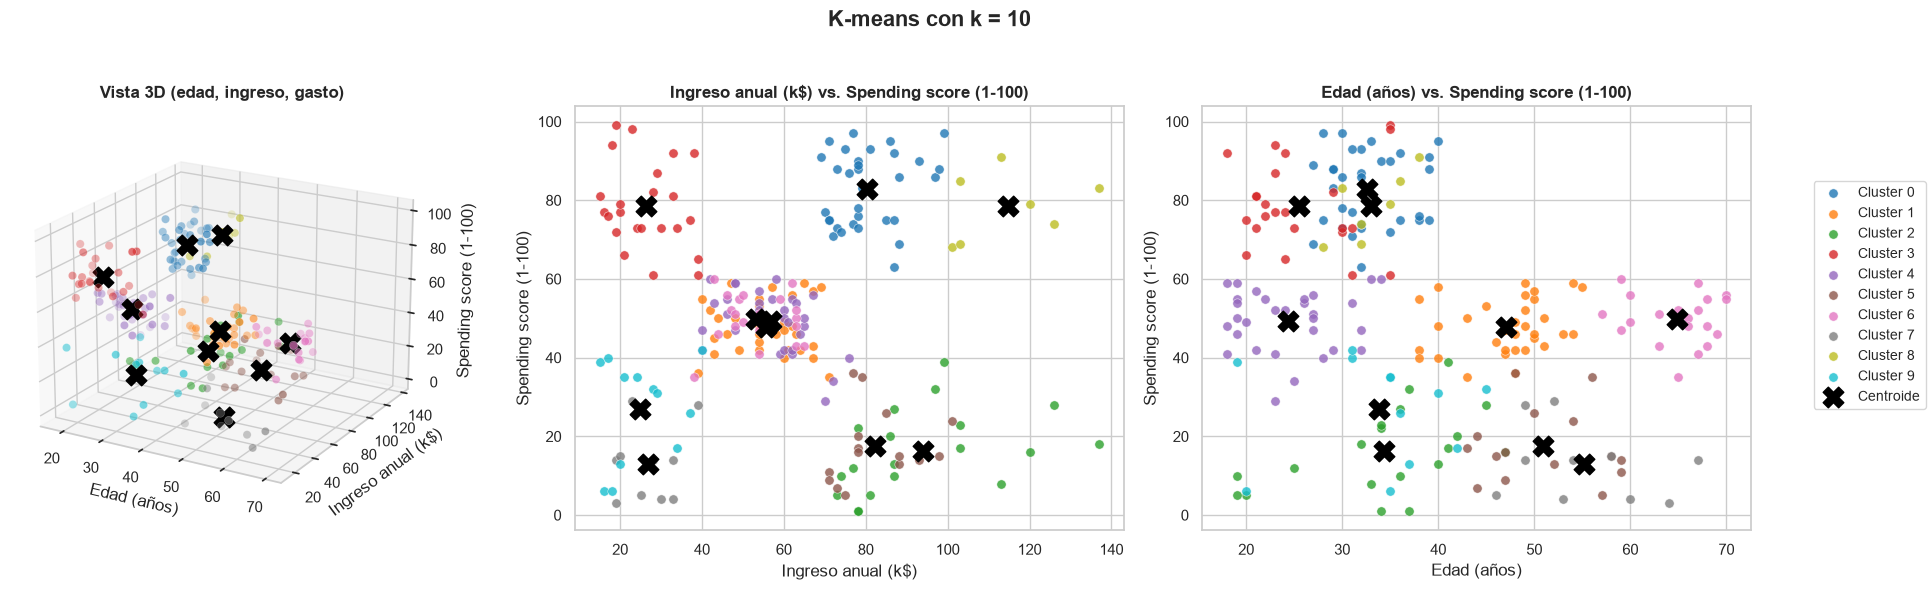

Inercia (WCSS): 82.39   |   Coeficiente de silueta: 0.407


,n_clientes,edad_media,ingreso_medio_k,gasto_medio,pct_mujeres
cluster,,,,,
0,32,32.6,80.4,82.9,53.1
1,32,47.1,55.6,47.8,65.6
2,19,34.3,93.9,16.2,42.1
3,23,25.5,26.3,78.6,60.9
4,30,24.3,56.9,49.4,63.3
5,15,50.9,82.2,17.5,46.7
6,20,64.8,53.2,49.8,40.0
7,10,55.2,26.9,13.0,50.0
8,7,33.0,114.7,78.4,57.1


In [10]:
ejecutar_k(10)

**Lectura:** con 10 clusters empezamos a **sobresegmentar**: aparecen grupos muy pequeños (7, 10 o 12 clientes) y varios grupos casi idénticos que solo difieren un poco en edad o ingreso. La inercia sigue bajando (82), pero eso es engañoso: la inercia **siempre** disminuye al aumentar $k$ (en el extremo, con $k = n$ cada cliente es su propio cluster y la inercia es 0).

Para el negocio, 10 segmentos tan finos son difíciles de accionar (¿10 campañas distintas para 200 clientes?) y un grupo de 7 personas es estadísticamente frágil: sus medias cambian mucho con un solo cliente más o menos.

In [11]:
# Comparación de los cinco modelos
comparacion = pd.DataFrame(resultados).T
comparacion.index.name = 'k'
comparacion.round(3)

,inercia,silueta
k,,
3,295.212,0.358
4,205.225,0.404
5,168.248,0.417
6,133.868,0.428
10,82.385,0.407


## 5. Método del codo (Elbow Method)

**Idea:** entrenamos K-means para $k = 1, 2, \dots, 15$ y graficamos la inercia $J(k)$.

- $J(k)$ **siempre baja** al aumentar $k$: más centroides implica que cada punto tiene uno más cerca.
- Al principio la caída es grande (separamos grupos realmente distintos); después la caída se vuelve pequeña (solo partimos grupos que ya eran homogéneos).
- El **codo** es el punto donde la curva cambia de "caída fuerte" a "caída suave": a partir de ahí, agregar clusters da **rendimientos decrecientes**.

**¿Cómo detectarlo sin "a ojo"?** Normalizamos ambos ejes a $[0, 1]$, trazamos la recta que une el primer punto $(k=1)$ con el último $(k=15)$ y buscamos el $k$ cuya distancia a esa recta es **máxima** (es la idea del algoritmo *Kneedle*). Tras normalizar, la recta va de $(0, 1)$ a $(1, 0)$, es decir $x + y - 1 = 0$, y la distancia de un punto $(x_n, y_n)$ a ella es:

$$d = \frac{|x_n + y_n - 1|}{\sqrt{2}}$$

**Desventajas del método del codo:**
- A menudo el codo **no es nítido** y la elección es subjetiva.
- El resultado depende del **rango de $k$** que se pruebe.
- Solo mide **compacidad** (qué tan cerca están los puntos de su centroide), no **separación** entre clusters.

**Alternativas / complementos:** coeficiente de silueta (lo calculamos abajo), índice de Davies-Bouldin, índice de Calinski-Harabasz, *Gap statistic*. La librería `yellowbrick` (ya incluida en `requirements.txt`) tiene `KElbowVisualizer`, que automatiza esta gráfica.

In [12]:
# Entrenamos K-means para k = 1..15 y guardamos la inercia (WCSS) de cada modelo
rango_k = list(range(1, 16))
inercias = []
for k in rango_k:
    modelo = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA)
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)


def detectar_codo(ks, valores):
    # Normalizamos ambos ejes a [0, 1] para que la distancia no dependa de las unidades
    x = np.array(ks, dtype=float)
    y = np.array(valores, dtype=float)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())
    # Distancia de cada punto a la recta que une el primer y el último punto: x + y - 1 = 0
    distancias = np.abs(x_n + y_n - 1) / np.sqrt(2)
    return int(x[np.argmax(distancias)]), distancias


k_codo, distancias = detectar_codo(rango_k, inercias)

# Tabla de apoyo: inercia, cuánto baja respecto al k anterior y distancia a la recta
tabla_codo = pd.DataFrame({
    'k': rango_k,
    'inercia': np.round(inercias, 2),
    'reduccion_vs_k_anterior_%': np.round(np.r_[np.nan, -np.diff(inercias) / np.array(inercias[:-1]) * 100], 1),
    'distancia_a_recta': np.round(distancias, 3)
}).set_index('k')

print(f'Codo detectado (máxima distancia a la recta): k = {k_codo}')
tabla_codo

Codo detectado (máxima distancia a la recta): k = 4


,inercia,reduccion_vs_k_anterior_%,distancia_a_recta
k,,,
1,600.00,NaN,0.000
2,389.39,35.1,0.223
3,295.21,24.2,0.295
4,205.23,30.5,0.361
5,168.25,18.0,0.359
6,133.87,20.4,0.353
7,117.01,12.6,0.324
8,103.87,11.2,0.291
9,93.09,10.4,0.254


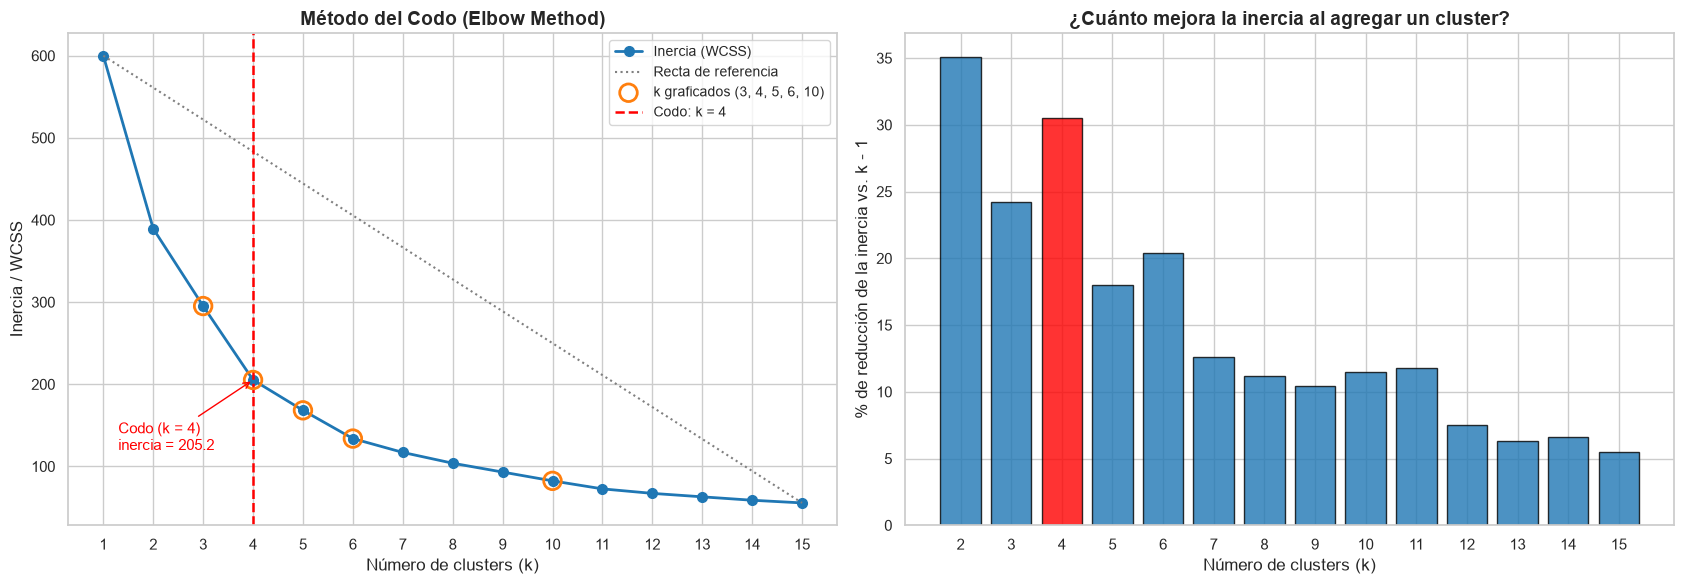

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

# --- Gráfica del codo ---
ax1.plot(rango_k, inercias, marker='o', color='#1f77b4', linewidth=2, markersize=7, label='Inercia (WCSS)')
# Recta de referencia entre el primer y el último punto (la que usa el detector)
ax1.plot([rango_k[0], rango_k[-1]], [inercias[0], inercias[-1]], linestyle=':', color='gray', label='Recta de referencia')
# Resaltamos los k que graficamos en la sección 4
k_evaluados = [3, 4, 5, 6, 10]
ax1.scatter(k_evaluados, [inercias[k - 1] for k in k_evaluados], s=160, facecolors='none',
            edgecolors='#ff7f0e', linewidths=2, label='k graficados (3, 4, 5, 6, 10)', zorder=3)
# Marcamos el codo
ax1.axvline(k_codo, color='red', linestyle='--', linewidth=1.8, label=f'Codo: k = {k_codo}')
ax1.annotate(f'Codo (k = {k_codo})\ninercia = {inercias[k_codo - 1]:.1f}',
             xy=(k_codo, inercias[k_codo - 1]), xytext=(1.3, 120),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red', ha='left')
ax1.set_xticks(rango_k)
ax1.set_xlabel('Número de clusters (k)', fontsize=12)
ax1.set_ylabel('Inercia / WCSS', fontsize=12)
ax1.set_title('Método del Codo (Elbow Method)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)

# --- Reducción porcentual de la inercia: visualiza los "rendimientos decrecientes" ---
reduccion = tabla_codo['reduccion_vs_k_anterior_%'].iloc[1:]
colores_barras = ['red' if k == k_codo else '#1f77b4' for k in reduccion.index]
ax2.bar(reduccion.index, reduccion.values, color=colores_barras, edgecolor='black', alpha=0.8)
ax2.set_xticks(reduccion.index)
ax2.set_xlabel('Número de clusters (k)', fontsize=12)
ax2.set_ylabel('% de reducción de la inercia vs. k - 1', fontsize=12)
ax2.set_title('¿Cuánto mejora la inercia al agregar un cluster?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Lectura del codo:**
- De $k=1$ a $k=4$ la inercia cae con fuerza (−35%, −24%, −30%): cada cluster nuevo separa grupos realmente diferentes.
- A partir de $k=5$ las reducciones son menores (−18%, −20%, −13%, …) y siguen bajando: rendimientos decrecientes.
- El detector geométrico ubica el **codo en k = 4**.

Pero el codo aquí es **suave**: en la tabla, la distancia a la recta de k = 4 (0.361) y la de k = 5 (0.359) prácticamente empatan, y k = 6 (0.353) queda muy cerca. No hay un quiebre brusco, así que conviene confirmar con otra métrica.

### Complemento: coeficiente de silueta

Para cada cliente $i$:
- $a(i)$ = distancia media a los puntos de **su propio** cluster (cohesión).
- $b(i)$ = distancia media a los puntos del cluster **vecino más cercano** (separación).

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \in [-1, 1]$$

- $s \approx 1$: el cliente está bien asignado y lejos del cluster vecino.
- $s \approx 0$: está en la frontera entre dos clusters.
- $s < 0$: probablemente está en el cluster equivocado.

La silueta del modelo es el promedio de todos los $s(i)$. A diferencia de la inercia, **no mejora automáticamente** al aumentar $k$, porque también mide separación. (No está definida para $k=1$.)

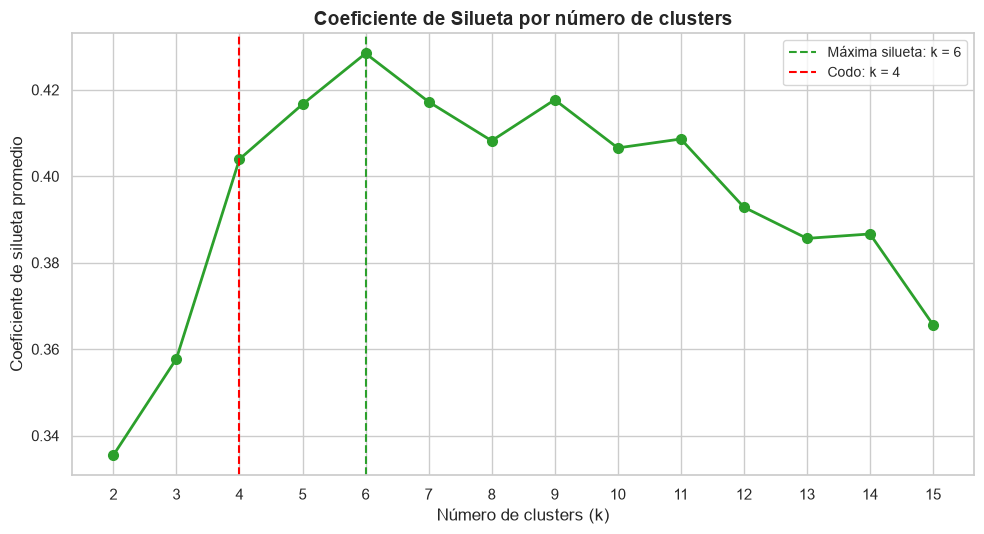

k
2     0.335
3     0.358
4     0.404
5     0.417
6     0.428
7     0.417
8     0.408
9     0.418
10    0.407
11    0.409
12    0.393
13    0.386
14    0.387
15    0.366


In [14]:
# Silueta para k = 2..15 (con k = 1 no existe cluster vecino, por eso empezamos en 2)
rango_k_sil = list(range(2, 16))
siluetas = []
for k in rango_k_sil:
    etiquetas = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEMILLA).fit_predict(X_scaled)
    siluetas.append(silhouette_score(X_scaled, etiquetas))

k_mejor_sil = rango_k_sil[int(np.argmax(siluetas))]

plt.figure(figsize=(10, 5.5))
plt.plot(rango_k_sil, siluetas, marker='o', color='#2ca02c', linewidth=2, markersize=7)
plt.axvline(k_mejor_sil, color='#2ca02c', linestyle='--', label=f'Máxima silueta: k = {k_mejor_sil}')
plt.axvline(k_codo, color='red', linestyle='--', label=f'Codo: k = {k_codo}')
plt.xticks(rango_k_sil)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Coeficiente de silueta promedio', fontsize=12)
plt.title('Coeficiente de Silueta por número de clusters', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(pd.Series(np.round(siluetas, 3), index=pd.Index(rango_k_sil, name='k'), name='silueta').to_string())

## 6. Conclusiones

| Criterio | k sugerido | Comentario |
|---|---|---|
| Método del codo | **4** | Último punto con una caída de inercia grande (−30%). |
| Coeficiente de silueta | **6** | Máximo en 0.428; k = 5 queda muy cerca (0.417). |
| Interpretabilidad (EDA) | **5** | Coincide con los 5 grupos visibles en ingreso vs. gasto. |

**¿Por qué no coinciden?** Porque miden cosas distintas: el codo solo mira **compacidad**; la silueta mira compacidad **y** separación. Cuando el codo es suave, lo normal es que las métricas propongan valores cercanos pero no idénticos. No existe un "k verdadero": $k$ es una **decisión de modelado** que combina matemáticas y utilidad para el negocio.

**Recomendación:** el rango razonable es **k ∈ {4, 5, 6}**; con k = 10 ya hay sobresegmentación (grupos de 7–12 clientes).
- **k = 4:** el más simple y el que marca el codo, pero todavía mezcla a los clientes de ingreso bajo con distinto gasto.
- **k = 5:** buen equilibrio entre métricas (silueta 0.417) e interpretabilidad; cada grupo tiene 20 clientes o más.
- **k = 6:** la mejor silueta; separa el grupo "medio" por edad y aísla a los jóvenes impulsivos.

**Siguiente paso sugerido:** elegir entre 4, 5 y 6 con un criterio de negocio (¿cuántas estrategias de marketing distintas puede ejecutar la empresa?) y, si se quiere más evidencia, revisar el **diagrama de silueta por cluster** (para detectar grupos con muchos clientes mal asignados) y la **estabilidad** de los clusters con distintas semillas.